<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Bhoomi Tulsiyani | 23010101275</b></center>
    
<center><b><h1>ML & DL</b></center>

<center><b><h1>Lab - 9 </b></center>
<center><b><h1>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

/Users/jayesh/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jayesh/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [ ]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [ ]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Step 4: Display PairPlot

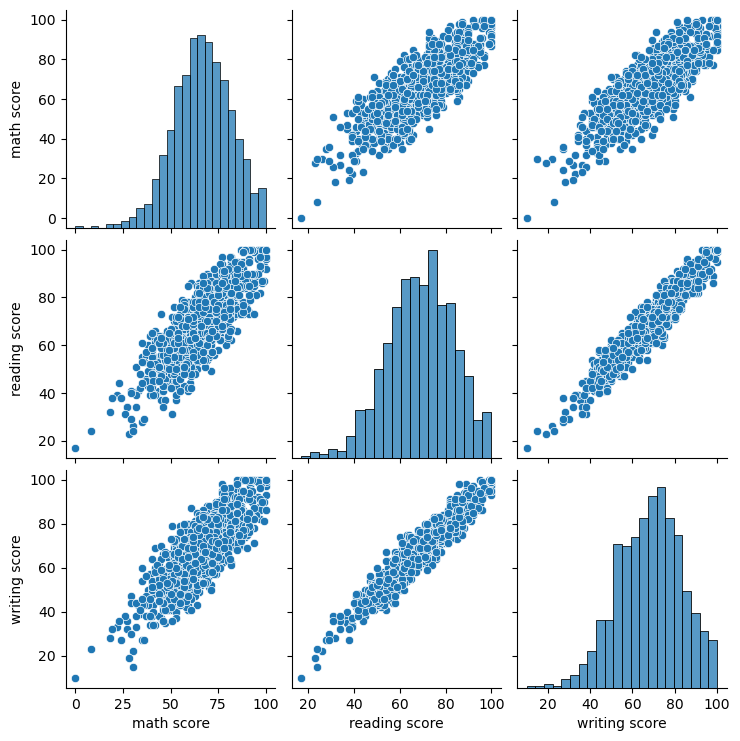

In [ ]:
sns.pairplot(df)
plt.show()

# Step 5: Correlation heatmap

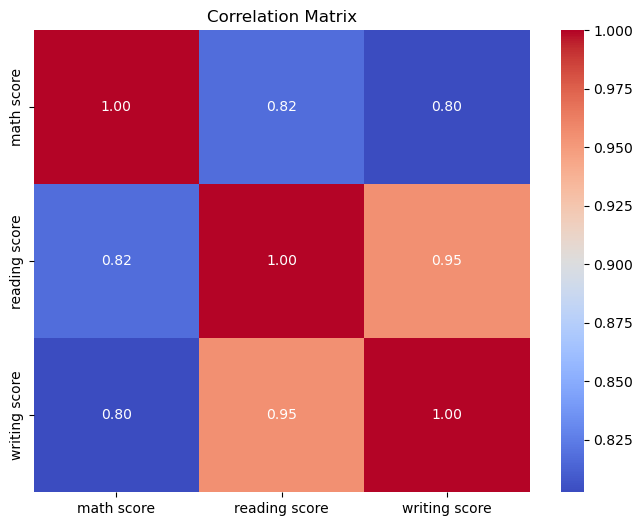

In [ ]:
plt.figure(figsize=(8, 6))

numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Step 6: Distribution of numerical features

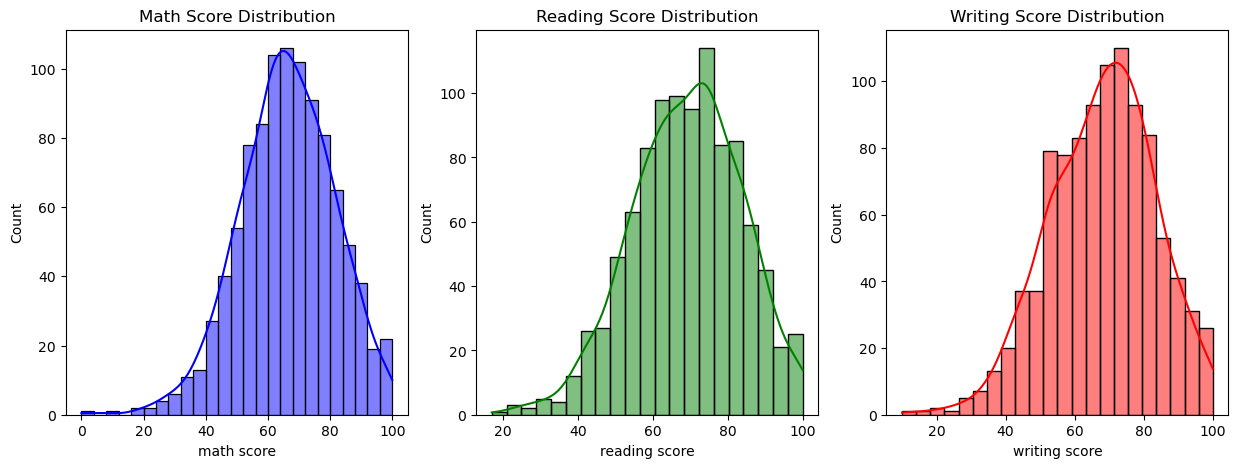

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['math score'], kde=True, color='blue')
plt.title('Math Score Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['reading score'], kde=True, color='green')
plt.title('Reading Score Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['writing score'], kde=True, color='red')
plt.title('Writing Score Distribution')

plt.show()

# Step 7: Apply StandardScaler

In [ ]:
X = df[['math score', 'reading score', 'writing score']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

   math score  reading score  writing score
0    0.390024       0.193999       0.391492
1    0.192076       1.427476       1.313269
2    1.577711       1.770109       1.642475
3   -1.259543      -0.833899      -1.583744
4    0.653954       0.605158       0.457333


# Step 8: Elbow method to find optimal k

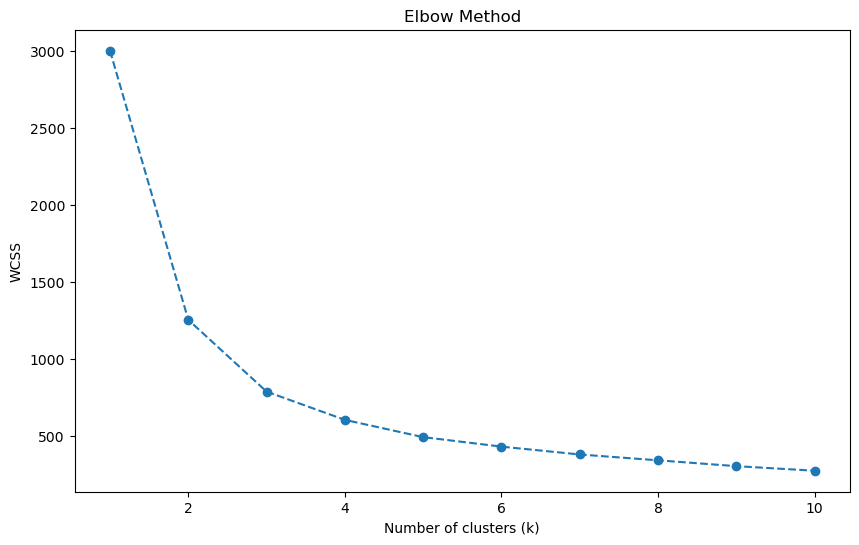

In [ ]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'] = y_kmeans

# Step 10: Print Cluster Center

In [ ]:
print("Cluster Centers (Scaled):")
print(kmeans.cluster_centers_)

print("\nCluster Centers (Original Scale):")
print(scaler.inverse_transform(kmeans.cluster_centers_))

Cluster Centers (Scaled):
[[ 1.03099793  1.09485536  1.06358515]
 [-1.18720058 -1.26762535 -1.28838441]
 [-0.04951336 -0.04870596 -0.01529686]]

Cluster Centers (Original Scale):
[[81.71428571 85.1461039  84.20779221]
 [48.09638554 50.67068273 48.48594378]
 [65.33860045 68.45823928 67.82167043]]


# Step 11:Analyze clusters 

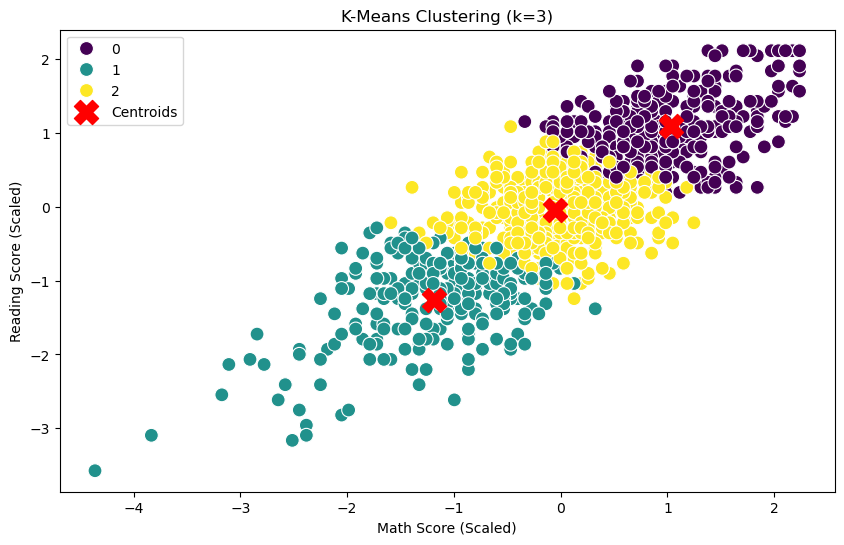

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_kmeans, palette='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='X', label='Centroids')
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.xlabel('Math Score (Scaled)')
plt.ylabel('Reading Score (Scaled)')
plt.legend()
plt.show()

# Step 12: Perform K-Medoids

In [ ]:
try:
    kmedoids = KMedoids(n_clusters=optimal_k, random_state=42, method='pam')
    y_kmedoids = kmedoids.fit_predict(X_scaled)
    
    df['Cluster_KMedoids'] = y_kmedoids
    print("K-Medoids fitted successfully.")
except NameError:
    print("KMedoids library not imported. Ensure scikit-learn-extra is installed.")

KMedoids library not imported. Ensure scikit-learn-extra is installed.


In [ ]:
if 'y_kmedoids' in locals():
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_kmedoids, palette='deep', s=100)
    plt.scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1], 
                s=300, c='orange', marker='X', label='Medoids')
    plt.title(f'K-Medoids Clustering (k={optimal_k})')
    plt.xlabel('Math Score (Scaled)')
    plt.ylabel('Reading Score (Scaled)')
    plt.legend()
    plt.show()

# Step:13 Comparison of K-means and K-medoids Clusters

In [ ]:
print("K-Means Cluster Counts:")
print(df['Cluster_KMeans'].value_counts().sort_index())

if 'Cluster_KMedoids' in df.columns:
    print("\nK-Medoids Cluster Counts:")
    print(df['Cluster_KMedoids'].value_counts().sort_index())
    
    print("\nK-Means Centroids (Original Scale):")
    print(scaler.inverse_transform(kmeans.cluster_centers_))
    
    print("\nK-Medoids Medoids (Original Scale):")
    print(scaler.inverse_transform(kmedoids.cluster_centers_))

K-Means Cluster Counts:
Cluster_KMeans
0    308
1    249
2    443
Name: count, dtype: int64


# Step: 14 | USE KMEAN++

In [ ]:
kmeans_plus = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
y_kmeans_plus = kmeans_plus.fit_predict(X_scaled)

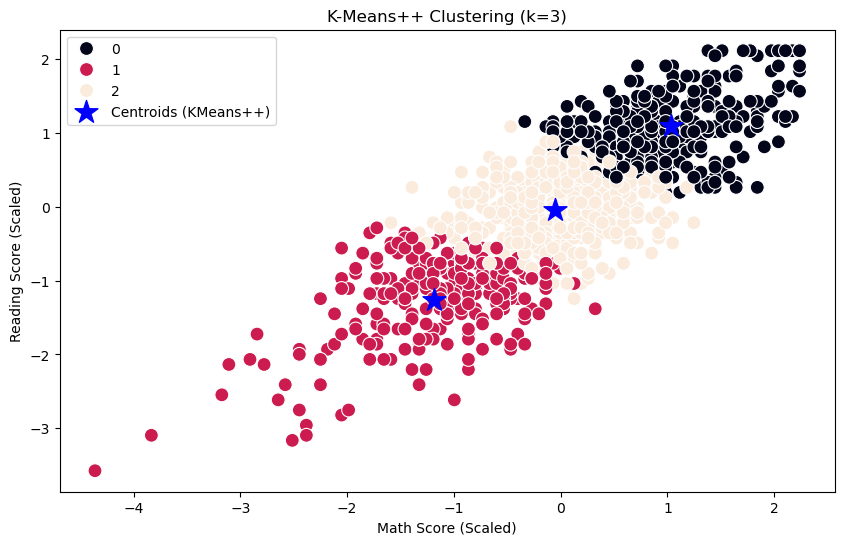

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_kmeans_plus, palette='rocket', s=100)

plt.scatter(kmeans_plus.cluster_centers_[:, 0], kmeans_plus.cluster_centers_[:, 1], 
            s=300, c='blue', marker='*', label='Centroids (KMeans++)')

plt.title(f'K-Means++ Clustering (k={optimal_k})')
plt.xlabel('Math Score (Scaled)')
plt.ylabel('Reading Score (Scaled)')
plt.legend()
plt.show()